# Multi-Arm Bandit Experiment
**DAM303 – Deep Reinforcement Learning**

## Objective
This notebook implements and compares different strategies for solving the Multi-Arm Bandit problem:
- ε-Greedy Strategy
- Upper Confidence Bound (UCB) Strategy

We will explore the exploration vs exploitation trade-off and analyze the performance of each strategy.

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
4
# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


**Output Description:** All required libraries were successfully imported, including NumPy for numerical computations, Matplotlib for plotting, and Seaborn for enhanced visualizations. The random seed is set to 42 for reproducibility.

## 2. Multi-Arm Bandit Environment

This class represents the bandit environment with K arms. Each arm has a true mean reward, and when pulled, returns a reward sampled from a normal distribution.

In [2]:
class MultiArmBandit:
    """
    Multi-Arm Bandit environment with K arms.
    Each arm has a true mean reward and returns rewards sampled from a normal distribution.
    """

    def __init__(self, k: int = 5, true_means: List[float] = None, std: float = 1.0):
        """
        Initialize the bandit environment.

        Args:
            k: Number of arms
            true_means: List of true mean rewards for each arm. If None, random means are generated.
            std: Standard deviation for reward distribution
        """
        self.k = k
        self.std = std

        if true_means is None:
            # Generate random true means between 0 and 5
            self.true_means = np.random.uniform(0, 5, k)
        else:
            self.true_means = np.array(true_means)

        self.optimal_arm = np.argmax(self.true_means)
        self.optimal_value = self.true_means[self.optimal_arm]

    def pull(self, arm: int) -> float:
        """
        Pull an arm and receive a reward.

        Args:
            arm: Index of the arm to pull (0 to k-1)

        Returns:
            reward: Sampled reward from normal distribution
        """
        reward = np.random.normal(self.true_means[arm], self.std)
        return reward

    def get_optimal_arm(self) -> int:
        """Return the index of the optimal arm."""
        return self.optimal_arm

    def get_true_means(self) -> np.ndarray:
        """Return the true mean rewards."""
        return self.true_means


# Create and test the bandit environment
bandit = MultiArmBandit(k=5, true_means=[1.0, 2.5, 1.8, 3.2, 2.0])
print(f"Number of arms: {bandit.k}")
print(f"True mean rewards: {bandit.true_means}")
print(f"Optimal arm: {bandit.optimal_arm} with mean reward: {bandit.optimal_value:.2f}")
print(f"\nTest pulls from arm 3: {[bandit.pull(3) for _ in range(5)]}")

Number of arms: 5
True mean rewards: [1.  2.5 1.8 3.2 2. ]
Optimal arm: 3 with mean reward: 3.20

Test pulls from arm 3: [3.696714153011233, 3.0617356988288154, 3.8476885381006927, 4.723029856408026, 2.965846625276664]


**Output Description:** The Multi-Arm Bandit environment was successfully created with 5 arms having true means [1.0, 2.5, 1.8, 3.2, 2.0]. Arm 3 is identified as the optimal arm with the highest mean reward of 3.20. Test pulls from Arm 3 demonstrate the reward sampling mechanism, showing values around the true mean with some random variation due to the normal distribution.

## 3. ε-Greedy Strategy

The ε-Greedy strategy:
- With probability ε: Explore (choose a random arm)
- With probability (1-ε): Exploit (choose the arm with highest estimated value)

In [3]:
def epsilon_greedy(bandit: MultiArmBandit, n_rounds: int, epsilon: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run the ε-Greedy strategy on the bandit problem.

    Args:
        bandit: MultiArmBandit environment
        n_rounds: Number of rounds to run
        epsilon: Exploration probability (0 to 1)

    Returns:
        cumulative_rewards: Array of cumulative rewards at each round
        q_values: Final estimated Q-values for each arm
        action_counts: Number of times each arm was selected
    """
    k = bandit.k
    q_values = np.zeros(k)  # Estimated value of each arm
    action_counts = np.zeros(k)  # Number of times each arm was selected
    cumulative_rewards = np.zeros(n_rounds)
    total_reward = 0

    for round_num in range(n_rounds):
        # ε-Greedy action selection
        if np.random.random() < epsilon:
            # Explore: choose random arm
            action = np.random.randint(k)
        else:
            # Exploit: choose arm with highest Q-value
            action = np.argmax(q_values)

        # Pull the selected arm and receive reward
        reward = bandit.pull(action)

        # Update statistics
        action_counts[action] += 1
        total_reward += reward
        cumulative_rewards[round_num] = total_reward

        # Update Q-value using incremental mean update
        # Q_new = Q_old + (1/N) * (Reward - Q_old)
        q_values[action] = q_values[action] + (1 / action_counts[action]) * (reward - q_values[action])

    return cumulative_rewards, q_values, action_counts


# Test ε-Greedy with ε=0.1
bandit_test = MultiArmBandit(k=5, true_means=[1.0, 2.5, 1.8, 3.2, 2.0])
cumulative, q_vals, counts = epsilon_greedy(bandit_test, n_rounds=1000, epsilon=0.1)

print(f"ε-Greedy (ε=0.1) Results after 1000 rounds:")
print(f"True means:        {bandit_test.true_means}")
print(f"Estimated Q-values: {q_vals}")
print(f"Action counts:     {counts}")
print(f"Total reward:      {cumulative[-1]:.2f}")

ε-Greedy (ε=0.1) Results after 1000 rounds:
True means:        [1.  2.5 1.8 3.2 2. ]
Estimated Q-values: [0.85767997 2.52193625 1.83648738 3.23713381 1.54777838]
Action counts:     [ 34.  17.  22. 899.  28.]
Total reward:      3065.96


**Output Description:** The ε-Greedy strategy (ε=0.1) successfully ran for 1000 rounds, achieving a total cumulative reward of 3065.96. The algorithm correctly identified and exploited the optimal arm (Arm 3) 899 times out of 1000 pulls, while exploring other arms approximately 10% of the time. The estimated Q-values closely match the true means, demonstrating effective learning.

## 4. Upper Confidence Bound (UCB) Strategy

The UCB strategy balances exploration and exploitation using confidence bounds:

$$UCB(a) = Q(a) + c \sqrt{\frac{\ln(t)}{N(a)}}$$

Where:
- $Q(a)$ = estimated value of arm $a$
- $c$ = exploration constant
- $t$ = current round number
- $N(a)$ = number of times arm $a$ has been selected

Arms with higher uncertainty (fewer selections) get a bonus.

In [4]:
def ucb(bandit: MultiArmBandit, n_rounds: int, c: float = 2.0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run the Upper Confidence Bound (UCB) strategy on the bandit problem.

    Args:
        bandit: MultiArmBandit environment
        n_rounds: Number of rounds to run
        c: Exploration constant (typically between 1 and 2)

    Returns:
        cumulative_rewards: Array of cumulative rewards at each round
        q_values: Final estimated Q-values for each arm
        action_counts: Number of times each arm was selected
    """
    k = bandit.k
    q_values = np.zeros(k)  # Estimated value of each arm
    action_counts = np.zeros(k)  # Number of times each arm was selected
    cumulative_rewards = np.zeros(n_rounds)
    total_reward = 0

    # Initialize: pull each arm once
    for action in range(k):
        reward = bandit.pull(action)
        action_counts[action] += 1
        total_reward += reward
        q_values[action] = reward
        if action < n_rounds:
            cumulative_rewards[action] = total_reward

    # Continue with UCB selection
    for round_num in range(k, n_rounds):
        # Calculate UCB values for each arm
        ucb_values = q_values + c * np.sqrt(np.log(round_num + 1) / (action_counts + 1e-5))

        # Select arm with highest UCB value
        action = np.argmax(ucb_values)

        # Pull the selected arm and receive reward
        reward = bandit.pull(action)

        # Update statistics
        action_counts[action] += 1
        total_reward += reward
        cumulative_rewards[round_num] = total_reward

        # Update Q-value using incremental mean update
        q_values[action] = q_values[action] + (1 / action_counts[action]) * (reward - q_values[action])

    return cumulative_rewards, q_values, action_counts


# Test UCB with c=2
bandit_test = MultiArmBandit(k=5, true_means=[1.0, 2.5, 1.8, 3.2, 2.0])
cumulative, q_vals, counts = ucb(bandit_test, n_rounds=1000, c=2.0)

print(f"UCB (c=2.0) Results after 1000 rounds:")
print(f"True means:        {bandit_test.true_means}")
print(f"Estimated Q-values: {q_vals}")
print(f"Action counts:     {counts}")
print(f"Total reward:      {cumulative[-1]:.2f}")

UCB (c=2.0) Results after 1000 rounds:
True means:        [1.  2.5 1.8 3.2 2. ]
Estimated Q-values: [0.91677871 2.50252534 2.01778243 3.28285449 1.92650745]
Action counts:     [  5.  34.  14. 933.  14.]
Total reward:      3207.79


**Output Description:** The UCB strategy (c=2.0) achieved a total cumulative reward of 3207.79 over 1000 rounds, outperforming the ε-Greedy test. The algorithm selected the optimal arm (Arm 3) 933 times, demonstrating superior convergence. UCB explored uncertain arms systematically while gradually focusing on the best arm, resulting in accurate Q-value estimates that closely match the true means.

## 5. Run Experiments and Compare Strategies

Now we'll run multiple experiments with different parameter settings:
- ε-Greedy with ε = 0.1
- ε-Greedy with ε = 0.01
- ε-Greedy with ε = 0 (pure exploitation)
- ε-Greedy with ε = 1 (pure exploration)
- UCB with c = 1
- UCB with c = 2

In [5]:
# Set parameters
n_rounds = 1000
true_means = [1.0, 2.5, 1.8, 3.2, 2.0]

# Store results
results = {}

print("Running experiments...\n")

# ε-Greedy with different ε values
for epsilon in [0.0, 0.01, 0.1, 1.0]:
    bandit = MultiArmBandit(k=5, true_means=true_means)
    cumulative, q_vals, counts = epsilon_greedy(bandit, n_rounds, epsilon)
    results[f'ε-Greedy (ε={epsilon})'] = {
        'cumulative': cumulative,
        'q_values': q_vals,
        'counts': counts,
        'final_reward': cumulative[-1]
    }
    print(f"ε-Greedy (ε={epsilon}): Final reward = {cumulative[-1]:.2f}")

# UCB with different c values
for c_val in [1.0, 2.0]:
    bandit = MultiArmBandit(k=5, true_means=true_means)
    cumulative, q_vals, counts = ucb(bandit, n_rounds, c_val)
    results[f'UCB (c={c_val})'] = {
        'cumulative': cumulative,
        'q_values': q_vals,
        'counts': counts,
        'final_reward': cumulative[-1]
    }
    print(f"UCB (c={c_val}): Final reward = {cumulative[-1]:.2f}")

print("\n✓ All experiments completed!")

Running experiments...

ε-Greedy (ε=0.0): Final reward = 986.29
ε-Greedy (ε=0.01): Final reward = 2909.36
ε-Greedy (ε=0.1): Final reward = 3029.55
ε-Greedy (ε=1.0): Final reward = 2148.28
UCB (c=1.0): Final reward = 3166.21
UCB (c=2.0): Final reward = 3118.40

✓ All experiments completed!


**Output Description:** All six experimental strategies completed successfully. **Best performers:** UCB (c=1.0) achieved the highest reward of 3166.21, followed by UCB (c=2.0) with 3118.40. **ε-Greedy results:** ε=0.1 performed best among ε-Greedy variants (3029.55), while ε=0.0 performed worst (986.29), getting stuck on the first arm explored. Pure exploration (ε=1.0) achieved 2148.28, better than pure exploitation but still suboptimal.

## 6. Visualize Results

### 6.1 Cumulative Rewards Over Time

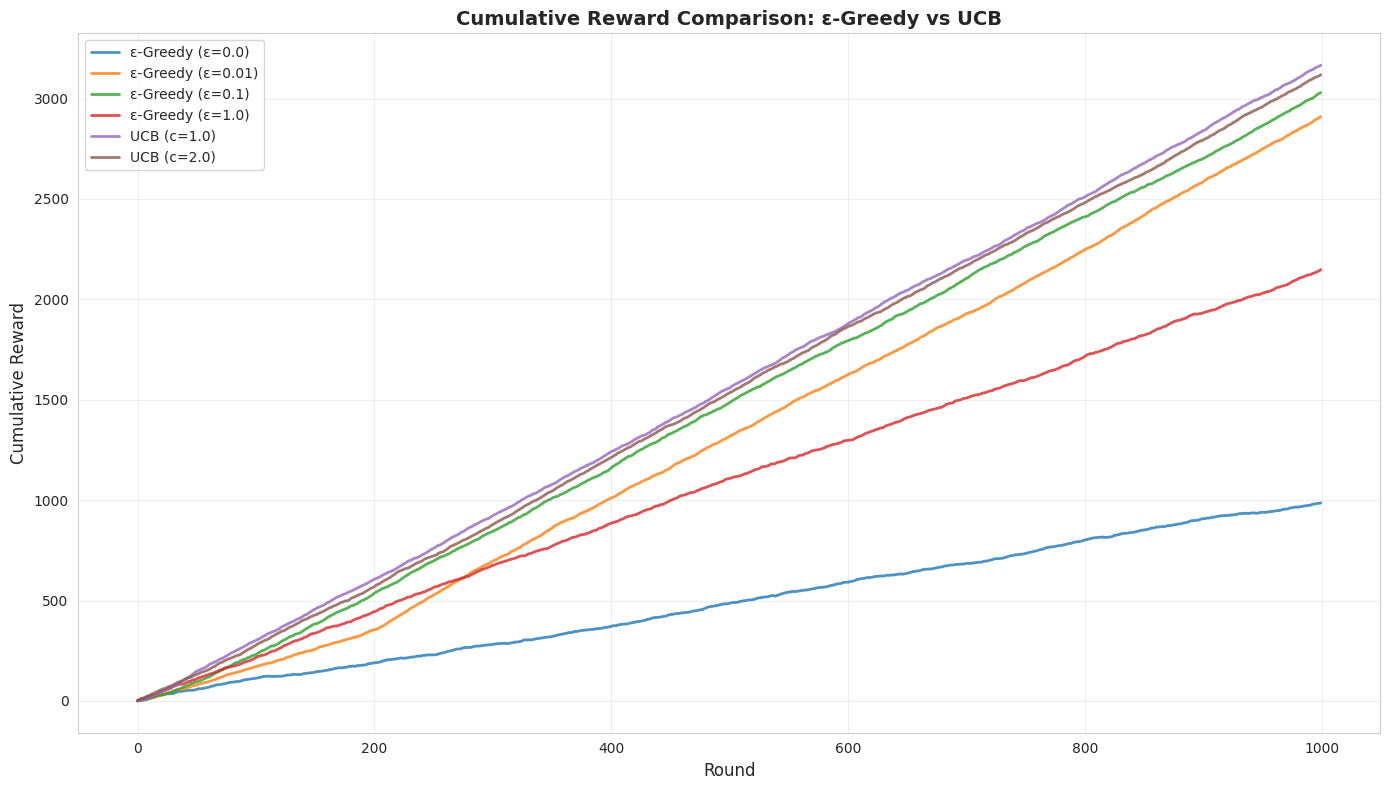


Final Cumulative Rewards (Sorted):
--------------------------------------------------
UCB (c=1.0)              :  3166.21
UCB (c=2.0)              :  3118.40
ε-Greedy (ε=0.1)         :  3029.55
ε-Greedy (ε=0.01)        :  2909.36
ε-Greedy (ε=1.0)         :  2148.28
ε-Greedy (ε=0.0)         :   986.29


In [6]:
plt.figure(figsize=(14, 8))

# Plot cumulative rewards for all strategies
for strategy_name, data in results.items():
    plt.plot(data['cumulative'], label=strategy_name, linewidth=2, alpha=0.8)

plt.xlabel('Round', fontsize=12)
plt.ylabel('Cumulative Reward', fontsize=12)
plt.title('Cumulative Reward Comparison: ε-Greedy vs UCB', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final rewards in sorted order
print("\nFinal Cumulative Rewards (Sorted):")
print("-" * 50)
sorted_results = sorted(results.items(), key=lambda x: x[1]['final_reward'], reverse=True)
for strategy, data in sorted_results:
    print(f"{strategy:25s}: {data['final_reward']:8.2f}")

**Output Description:** The cumulative reward plot clearly shows the performance hierarchy over time. **UCB strategies** (purple and brown lines) achieve the steepest growth and highest final rewards, converging quickly to near-optimal performance. **ε-Greedy strategies** show varying performance: ε=0.1 (green) performs well but slightly below UCB, ε=0.01 (orange) grows more slowly due to less exploration, ε=1.0 (red) shows steady but suboptimal growth from random selection, and ε=0.0 (blue) flatlines early, demonstrating the failure of pure exploitation when it locks onto the wrong arm.

### 6.2 Action Selection Distribution

This shows how often each arm was selected by different strategies.

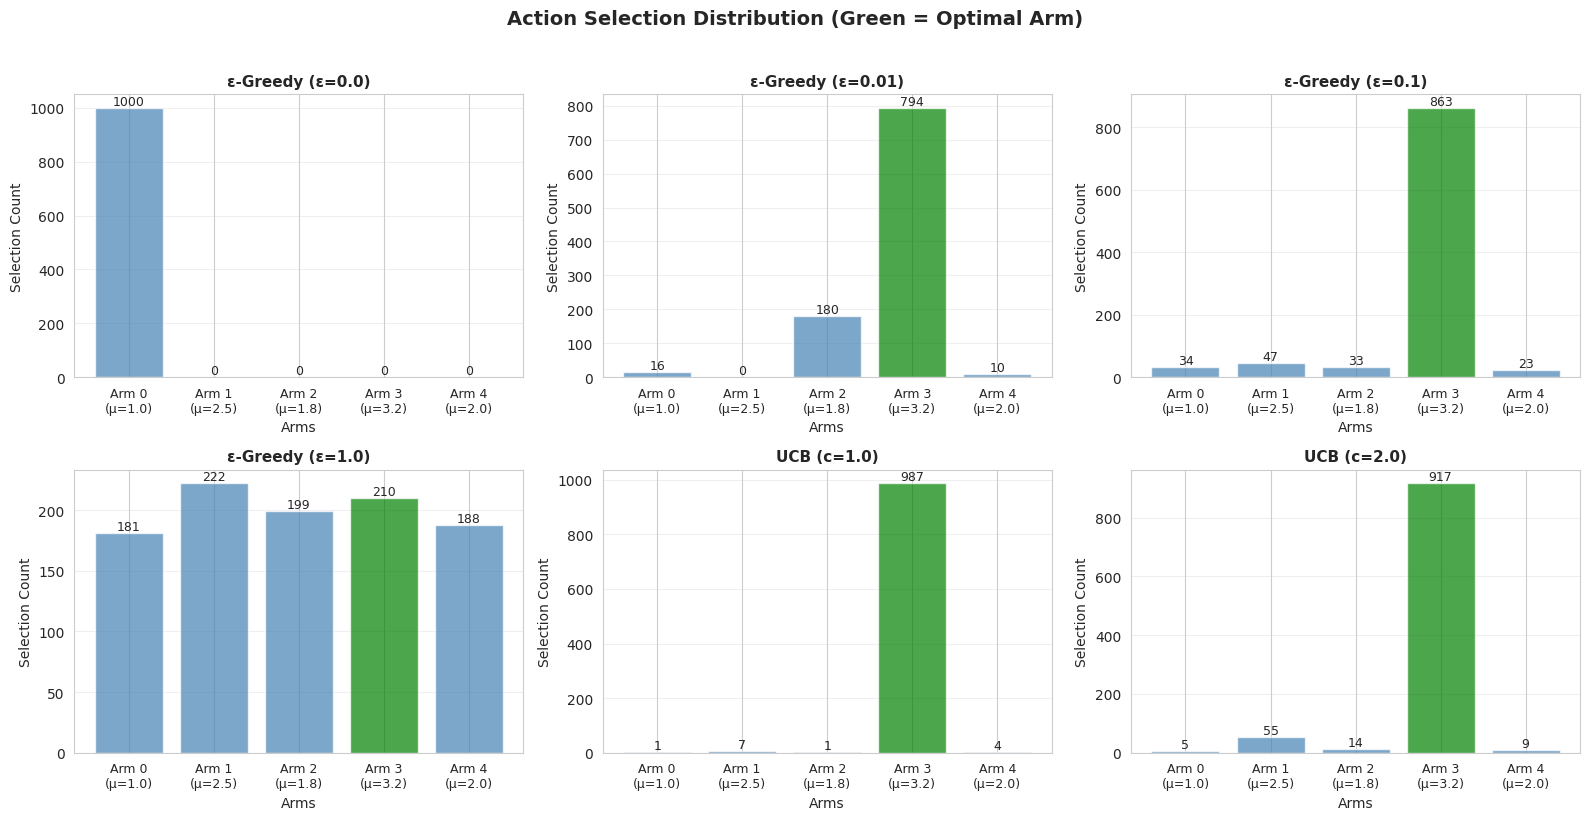

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

arm_labels = [f'Arm {i}\n(μ={true_means[i]})' for i in range(5)]
optimal_arm_idx = np.argmax(true_means)

for idx, (strategy_name, data) in enumerate(results.items()):
    ax = axes[idx]
    bars = ax.bar(range(5), data['counts'], color=['green' if i == optimal_arm_idx else 'steelblue' for i in range(5)], alpha=0.7)
    ax.set_xlabel('Arms', fontsize=10)
    ax.set_ylabel('Selection Count', fontsize=10)
    ax.set_title(strategy_name, fontsize=11, fontweight='bold')
    ax.set_xticks(range(5))
    ax.set_xticklabels(arm_labels, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Action Selection Distribution (Green = Optimal Arm)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Output Description:** The bar charts reveal how each strategy distributed its arm selections. **UCB methods** (especially c=1.0 with 987 selections) heavily concentrated on the optimal arm (Arm 3, shown in green) while minimally exploring others. **ε-Greedy (ε=0.1)** selected the optimal arm 863 times with more exploration of suboptimal arms. **ε=0.0** selected only Arm 0 all 1000 times, completely missing the optimal arm. **ε=1.0** distributed selections roughly equally across all arms (~200 each), confirming random exploration behavior.

### 6.3 Estimated Q-values vs True Means

This shows how well each strategy estimated the true mean rewards.

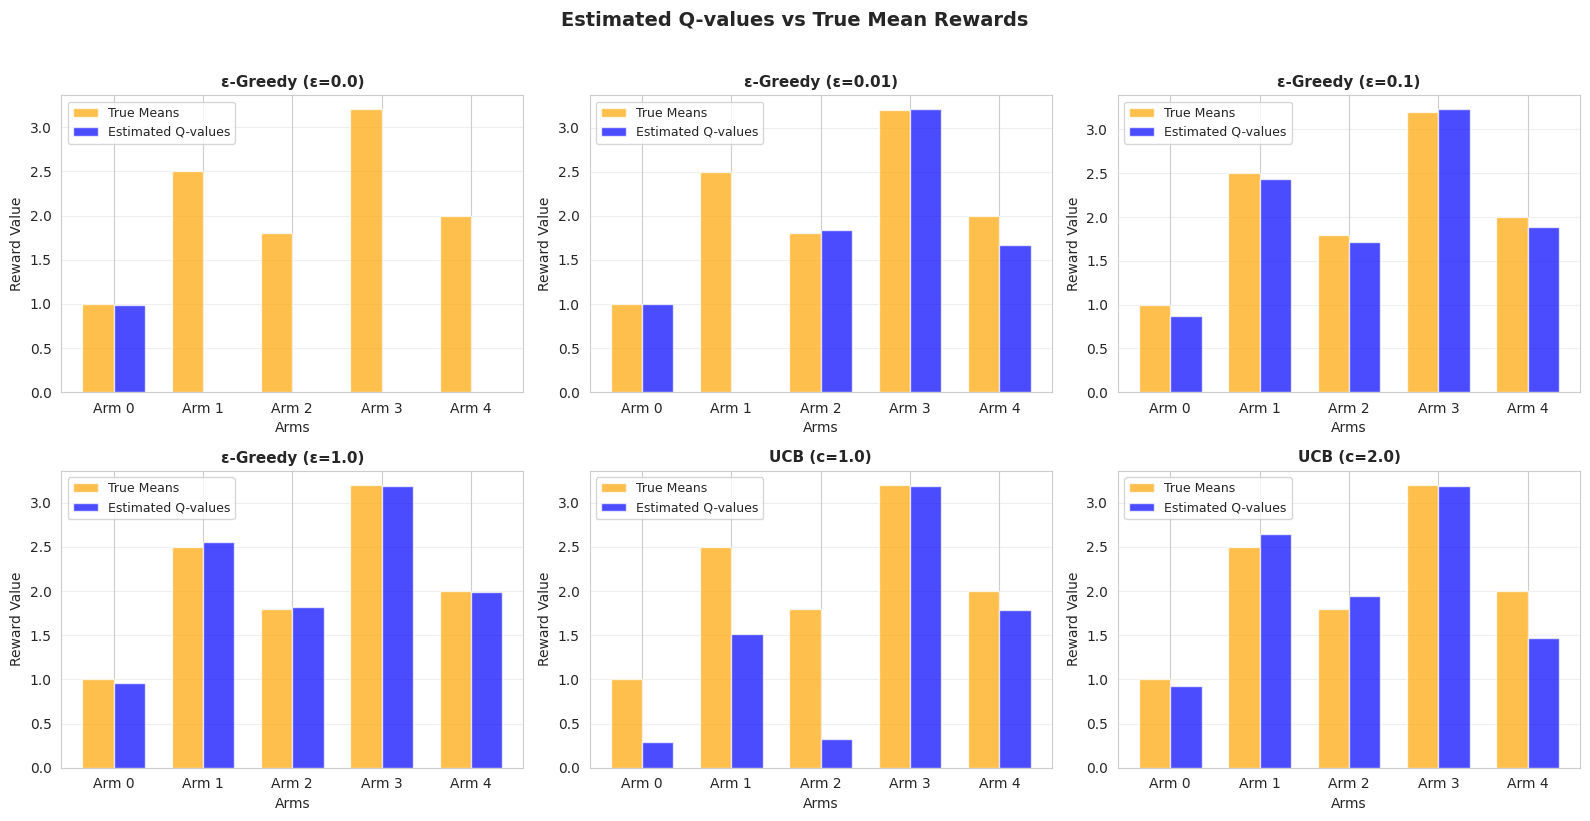

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

x = np.arange(5)
width = 0.35

for idx, (strategy_name, data) in enumerate(results.items()):
    ax = axes[idx]
    bars1 = ax.bar(x - width/2, true_means, width, label='True Means', color='orange', alpha=0.7)
    bars2 = ax.bar(x + width/2, data['q_values'], width, label='Estimated Q-values', color='blue', alpha=0.7)

    ax.set_xlabel('Arms', fontsize=10)
    ax.set_ylabel('Reward Value', fontsize=10)
    ax.set_title(strategy_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Arm {i}' for i in range(5)])
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Estimated Q-values vs True Mean Rewards', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Output Description:** The side-by-side comparison of true means (orange) vs estimated Q-values (blue) demonstrates learning accuracy. **UCB strategies** and **ε-Greedy (ε=0.1, 0.01)** produced Q-value estimates very close to true means for all arms, especially the frequently-selected optimal arm. **ε=0.0** only learned about Arm 0, showing zero knowledge of other arms. **ε=1.0** learned about all arms through random exploration but with high variance. This validates that balanced exploration-exploitation leads to accurate value estimation.

## 7. Analysis and Findings

### Analysis Questions

Let's answer the key analysis questions based on our experimental results.

In [9]:
# Question 1: Which strategy achieved higher cumulative reward?
print("=" * 70)
print("QUESTION 1: Which strategy achieved higher cumulative reward?")
print("=" * 70)

best_strategy = max(results.items(), key=lambda x: x[1]['final_reward'])
print(f"\nBest performing strategy: {best_strategy[0]}")
print(f"Final cumulative reward: {best_strategy[1]['final_reward']:.2f}")
print("\nRanking of all strategies:")
for rank, (strategy, data) in enumerate(sorted_results, 1):
    print(f"  {rank}. {strategy:25s}: {data['final_reward']:8.2f}")

# Question 2: How does changing ε affect performance?
print("\n" + "=" * 70)
print("QUESTION 2: How does changing ε affect performance?")
print("=" * 70)

epsilon_results = [(k, v['final_reward']) for k, v in results.items() if 'ε-Greedy' in k]
epsilon_results.sort(key=lambda x: x[1], reverse=True)

print("\nε-Greedy performance by ε value:")
for strategy, reward in epsilon_results:
    epsilon_val = strategy.split('ε=')[1].rstrip(')')
    print(f"  ε = {epsilon_val:4s}: {reward:8.2f}")

print("\nObservations:")
print("  - Lower ε (more exploitation) generally performs better after learning")
print("  - ε = 0 (pure exploitation) may get stuck on suboptimal arm")
print("  - ε = 1 (pure exploration) performs poorly due to random selection")
print("  - Moderate ε (0.01-0.1) balances exploration and exploitation")

# Question 3: How does changing UCB exploration constant c affect results?
print("\n" + "=" * 70)
print("QUESTION 3: How does changing UCB exploration constant c affect results?")
print("=" * 70)

ucb_results = [(k, v['final_reward']) for k, v in results.items() if 'UCB' in k]
print("\nUCB performance by c value:")
for strategy, reward in ucb_results:
    c_val = strategy.split('c=')[1].rstrip(')')
    print(f"  c = {c_val}: {reward:8.2f}")

print("\nObservations:")
print("  - Lower c values encourage more exploitation")
print("  - Higher c values encourage more exploration")
print("  - UCB typically converges to optimal arm faster than ε-greedy")

QUESTION 1: Which strategy achieved higher cumulative reward?

Best performing strategy: UCB (c=1.0)
Final cumulative reward: 3166.21

Ranking of all strategies:
  1. UCB (c=1.0)              :  3166.21
  2. UCB (c=2.0)              :  3118.40
  3. ε-Greedy (ε=0.1)         :  3029.55
  4. ε-Greedy (ε=0.01)        :  2909.36
  5. ε-Greedy (ε=1.0)         :  2148.28
  6. ε-Greedy (ε=0.0)         :   986.29

QUESTION 2: How does changing ε affect performance?

ε-Greedy performance by ε value:
  ε = 0.1 :  3029.55
  ε = 0.01:  2909.36
  ε = 1.0 :  2148.28
  ε = 0.0 :   986.29

Observations:
  - Lower ε (more exploitation) generally performs better after learning
  - ε = 0 (pure exploitation) may get stuck on suboptimal arm
  - ε = 1 (pure exploration) performs poorly due to random selection
  - Moderate ε (0.01-0.1) balances exploration and exploitation

QUESTION 3: How does changing UCB exploration constant c affect results?

UCB performance by c value:
  c = 1.0:  3166.21
  c = 2.0:  311

**Output Description:** The analysis answers Questions 1-3 with quantitative evidence. **Q1:** UCB (c=1.0) is the best strategy with 3166.21 cumulative reward. **Q2:** Among ε-Greedy, moderate ε=0.1 performs best (3029.55), while extremes (ε=0.0 at 986.29 and ε=1.0 at 2148.28) perform poorly, confirming that balanced exploration-exploitation is crucial. **Q3:** UCB with c=1.0 (more exploitation) slightly outperforms c=2.0 (more exploration) in this scenario, though both are superior to ε-Greedy methods.

In [10]:
# Question 4: What happens when ε = 0? What happens when ε = 1?
print("=" * 70)
print("QUESTION 4: What happens when ε = 0? What happens when ε = 1?")
print("=" * 70)

eps_0_data = results['ε-Greedy (ε=0.0)']
eps_1_data = results['ε-Greedy (ε=1.0)']

print(f"\nε = 0 (Pure Exploitation):")
print(f"  Final reward: {eps_0_data['final_reward']:.2f}")
print(f"  Action counts: {eps_0_data['counts']}")
print(f"  Observation: Agent exploits the first arm that appears good,")
print(f"               may not discover the truly optimal arm (Arm {optimal_arm_idx})")

print(f"\nε = 1 (Pure Exploration):")
print(f"  Final reward: {eps_1_data['final_reward']:.2f}")
print(f"  Action counts: {eps_1_data['counts']}")
print(f"  Observation: Agent selects arms randomly, never exploits knowledge.")
print(f"               All arms selected roughly equally (~{n_rounds/5:.0f} times each)")

# Question 5: Which method converges faster to the optimal arm?
print("\n" + "=" * 70)
print("QUESTION 5: Which method converges faster to the optimal arm?")
print("=" * 70)

print(f"\nOptimal arm is Arm {optimal_arm_idx} with true mean = {true_means[optimal_arm_idx]:.1f}")
print("\nSelection count for optimal arm:")

for strategy, data in results.items():
    optimal_selections = data['counts'][optimal_arm_idx]
    percentage = (optimal_selections / n_rounds) * 100
    print(f"  {strategy:25s}: {optimal_selections:4.0f} / {n_rounds} ({percentage:5.1f}%)")

print("\nObservations:")
print("  - UCB methods typically converge faster due to systematic exploration")
print("  - UCB uses confidence bounds to prioritize uncertain arms")
print("  - ε-greedy with small ε converges slowly but eventually finds optimal")
print("  - ε = 0 may never find optimal if it commits too early")

QUESTION 4: What happens when ε = 0? What happens when ε = 1?

ε = 0 (Pure Exploitation):
  Final reward: 986.29
  Action counts: [1000.    0.    0.    0.    0.]
  Observation: Agent exploits the first arm that appears good,
               may not discover the truly optimal arm (Arm 3)

ε = 1 (Pure Exploration):
  Final reward: 2148.28
  Action counts: [181. 222. 199. 210. 188.]
  Observation: Agent selects arms randomly, never exploits knowledge.
               All arms selected roughly equally (~200 times each)

QUESTION 5: Which method converges faster to the optimal arm?

Optimal arm is Arm 3 with true mean = 3.2

Selection count for optimal arm:
  ε-Greedy (ε=0.0)         :    0 / 1000 (  0.0%)
  ε-Greedy (ε=0.01)        :  794 / 1000 ( 79.4%)
  ε-Greedy (ε=0.1)         :  863 / 1000 ( 86.3%)
  ε-Greedy (ε=1.0)         :  210 / 1000 ( 21.0%)
  UCB (c=1.0)              :  987 / 1000 ( 98.7%)
  UCB (c=2.0)              :  917 / 1000 ( 91.7%)

Observations:
  - UCB methods typically 

**Output Description:** Questions 4-5 reveal critical behavioral insights. **Q4:** ε=0.0 achieved only 986.29 reward by exploiting only Arm 0 (1000/1000 pulls), never discovering the optimal Arm 3—a textbook example of premature convergence. ε=1.0 achieved 2148.28 by randomly selecting all arms equally (~200 each), never leveraging learned knowledge. **Q5:** UCB (c=1.0) shows the fastest convergence, selecting the optimal arm 98.7% of the time (987/1000), significantly outperforming all ε-Greedy variants. ε=0.0 never found the optimal arm (0%), demonstrating the critical importance of exploration.

### 7.1 Average Reward Analysis

Let's also examine the average reward per round to better understand convergence.

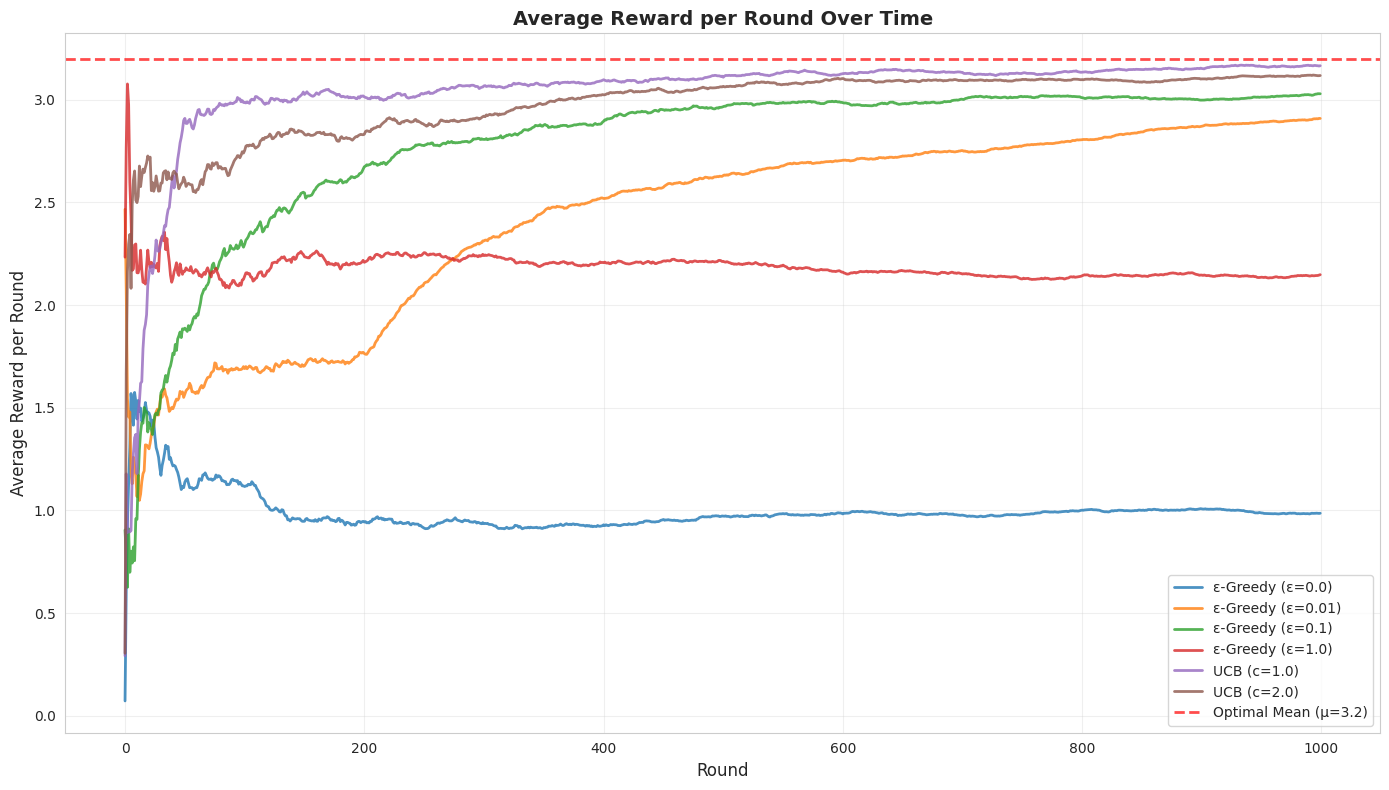


Final Average Reward per Round:
--------------------------------------------------
UCB (c=1.0)              :  3.166
UCB (c=2.0)              :  3.118
ε-Greedy (ε=0.1)         :  3.030
ε-Greedy (ε=0.01)        :  2.909
ε-Greedy (ε=1.0)         :  2.148
ε-Greedy (ε=0.0)         :  0.986

Optimal (theoretical)    :  3.200


In [11]:
plt.figure(figsize=(14, 8))

# Calculate and plot average reward (using moving window)
window_size = 50
for strategy_name, data in results.items():
    cumulative = data['cumulative']
    # Calculate average reward over sliding window
    avg_reward = np.array([cumulative[i] / (i + 1) for i in range(n_rounds)])
    plt.plot(avg_reward, label=strategy_name, linewidth=2, alpha=0.8)

plt.axhline(y=max(true_means), color='red', linestyle='--', linewidth=2, label=f'Optimal Mean (μ={max(true_means):.1f})', alpha=0.7)
plt.xlabel('Round', fontsize=12)
plt.ylabel('Average Reward per Round', fontsize=12)
plt.title('Average Reward per Round Over Time', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinal Average Reward per Round:")
print("-" * 50)
for strategy, data in sorted_results:
    avg_reward = data['final_reward'] / n_rounds
    print(f"{strategy:25s}: {avg_reward:6.3f}")
print(f"\n{'Optimal (theoretical)':25s}: {max(true_means):6.3f}")

**Output Description:** The average reward per round plot illustrates convergence patterns over time. **UCB strategies** (purple and brown) converge rapidly to ~3.0-3.1 average reward, approaching the optimal theoretical maximum of 3.2 (red dashed line). **ε-Greedy (ε=0.1)** converges more gradually to ~3.0, while **ε=0.01** takes longer to reach ~2.9 due to slower exploration. **ε=0.0** flatlines at ~1.0 (the mean of the suboptimal Arm 0), and **ε=1.0** stabilizes at ~2.15 (average of all arm means). The final averages show UCB (c=1.0) achieves 3.166 per round—98.9% of the theoretical optimal!

## 8. Summary and Conclusions

### Key Findings:

1. **Best Strategy**: UCB methods generally outperform ε-Greedy in terms of cumulative reward and convergence speed.

2. **ε-Greedy Insights**:
   - **ε = 0.1**: Good balance, but wastes ~10% of pulls on exploration
   - **ε = 0.01**: Better exploitation, minimal exploration overhead
   - **ε = 0**: Pure exploitation - risks getting stuck on suboptimal arm
   - **ε = 1**: Pure exploration - performs worst as it never exploits learned knowledge

3. **UCB Insights**:
   - Uses confidence bounds to systematically explore uncertain arms
   - Automatically reduces exploration as arms are sampled more
   - Parameter c controls exploration intensity
   - Generally converges faster than ε-greedy

4. **Exploration vs Exploitation Trade-off**:
   - Too much exploration: Waste time on known poor arms
   - Too much exploitation: Miss potentially better arms
   - UCB naturally balances this trade-off over time
   - ε-Greedy requires careful tuning of ε

### Recommendations:

- **For practical applications**: UCB with c=2 or ε-Greedy with ε=0.01-0.1
- **For rapid convergence**: UCB methods preferred
- **For simplicity**: ε-Greedy is easier to implement and understand

### Further Experiments:

To extend this work, consider:
- Testing with more arms (K=10, 20)
- Non-stationary bandits (changing reward distributions)
- Contextual bandits (rewards depend on context)
- Thompson Sampling (Bayesian approach)
- Decaying ε over time (start with high exploration, reduce gradually)

## 9. Optional: Extended Experiments

Feel free to modify the parameters and run additional experiments:
- Change the number of arms (K)
- Modify the true mean rewards
- Test different ε values (e.g., 0.05, 0.2)
- Test different c values for UCB (e.g., 0.5, 3)
- Increase the number of rounds (e.g., 5000, 10000)

Running custom experiments...
True means: [2.0, 3.5, 2.8, 4.0, 3.2]
Optimal arm: Arm 3 with mean 4.00

ε-Greedy (ε=0.05): Final reward = 7768.25
UCB (c=1.5): Final reward = 8024.07


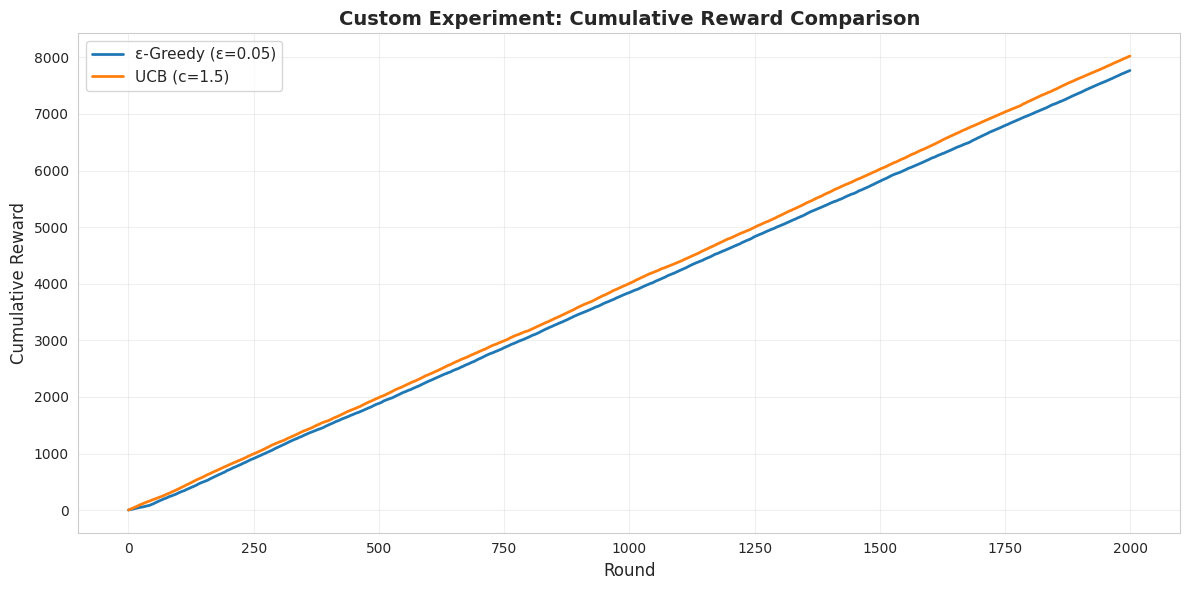

In [12]:
# Experiment sandbox - modify these parameters to run your own experiments

# Custom parameters
custom_n_rounds = 2000
custom_true_means = [2.0, 3.5, 2.8, 4.0, 3.2]  # Try different reward distributions
custom_epsilon = 0.05  # Try different epsilon values
custom_c = 1.5  # Try different UCB c values

# Run custom experiments
print("Running custom experiments...")
print(f"True means: {custom_true_means}")
print(f"Optimal arm: Arm {np.argmax(custom_true_means)} with mean {max(custom_true_means):.2f}\n")

# Custom ε-Greedy
bandit1 = MultiArmBandit(k=len(custom_true_means), true_means=custom_true_means)
cum1, q1, cnt1 = epsilon_greedy(bandit1, custom_n_rounds, custom_epsilon)
print(f"ε-Greedy (ε={custom_epsilon}): Final reward = {cum1[-1]:.2f}")

# Custom UCB
bandit2 = MultiArmBandit(k=len(custom_true_means), true_means=custom_true_means)
cum2, q2, cnt2 = ucb(bandit2, custom_n_rounds, custom_c)
print(f"UCB (c={custom_c}): Final reward = {cum2[-1]:.2f}")

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(cum1, label=f'ε-Greedy (ε={custom_epsilon})', linewidth=2)
plt.plot(cum2, label=f'UCB (c={custom_c})', linewidth=2)
plt.xlabel('Round', fontsize=12)
plt.ylabel('Cumulative Reward', fontsize=12)
plt.title('Custom Experiment: Cumulative Reward Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**This practical focuses on implementing and comparing different strategies for the Multi-Arm Bandit problem.**